<a href="https://colab.research.google.com/github/shubtheone/MNIST-using-torch/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
data = pd.read_csv('mnist_train.csv', header=None)
data = data.dropna()
data

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59997,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
data = np.array(data)
m,n=data.shape
np.random.shuffle(data)

data_dev=data[0:1000].T
y_dev=data_dev[0]
x_dev=data_dev[1:n]
x_dev=x_dev/255.0

data_train=data[1000:m].T
y_train=data_train[0]
x_train=data_train[1:n]
x_train=x_train/255.0

# make sure x_train is (num_samples, 784)
x_train = x_train.T
x_dev = x_dev.T

# Convert numpy arrays to PyTorch tensors and ensure correct data types, then move to device
x_train = torch.from_numpy(x_train).type(torch.float32).to(device)
y_train = torch.from_numpy(y_train).type(torch.long).to(device) # Change to torch.long for CrossEntropyLoss
x_dev = torch.from_numpy(x_dev).type(torch.float32).to(device)
y_dev = torch.from_numpy(y_dev).type(torch.long).to(device) # Change to torch.long for CrossEntropyLoss

In [ ]:
class linear1(nn.Module):
  def __init__(self):
    super().__init__()
    self.net=nn.Sequential(
        nn.Linear(784,128),
        nn.ReLU(),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Linear(64,10))
  def forward(self,x):
    return self.net(x)

In [ ]:
model=linear1().to(device)
model

linear1(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [ ]:
loss_fn = nn.CrossEntropyLoss() # Changed to CrossEntropyLoss for classification

optimizerr=torch.optim.Adam(model.parameters(),lr=0.001)

In [ ]:
epochs = 100
train_loss_values=[]
test_loss_values=[]
epoch_count=[]
for epoch in range(epochs):
  model.train()
  y_pred=model(x_train)
  loss=loss_fn(y_pred,y_train)
  optimizerr.zero_grad()
  loss.backward()
  optimizerr.step()

  # Evaluation loop (inside the epoch loop to log progress)
  model.eval()
  with torch.inference_mode():
      test_pred=model(x_dev)
      test_loss=loss_fn(test_pred,y_dev)

      if epoch % 10 == 0:
              epoch_count.append(epoch)
              train_loss_values.append(loss.item())
              test_loss_values.append(test_loss.item())

              print(f"Epoch: {epoch} | Train Loss: {loss:.4f} | Test Loss: {test_loss:.4f}")

Epoch: 0 | Train Loss: 0.0024 | Test Loss: 0.1503
Epoch: 10 | Train Loss: 0.0022 | Test Loss: 0.1518
Epoch: 20 | Train Loss: 0.0021 | Test Loss: 0.1533
Epoch: 30 | Train Loss: 0.0020 | Test Loss: 0.1546
Epoch: 40 | Train Loss: 0.0018 | Test Loss: 0.1559
Epoch: 50 | Train Loss: 0.0017 | Test Loss: 0.1572
Epoch: 60 | Train Loss: 0.0016 | Test Loss: 0.1586
Epoch: 70 | Train Loss: 0.0015 | Test Loss: 0.1599
Epoch: 80 | Train Loss: 0.0014 | Test Loss: 0.1613
Epoch: 90 | Train Loss: 0.0013 | Test Loss: 0.1627


In [ ]:
with torch.inference_mode():
  model(x_dev)

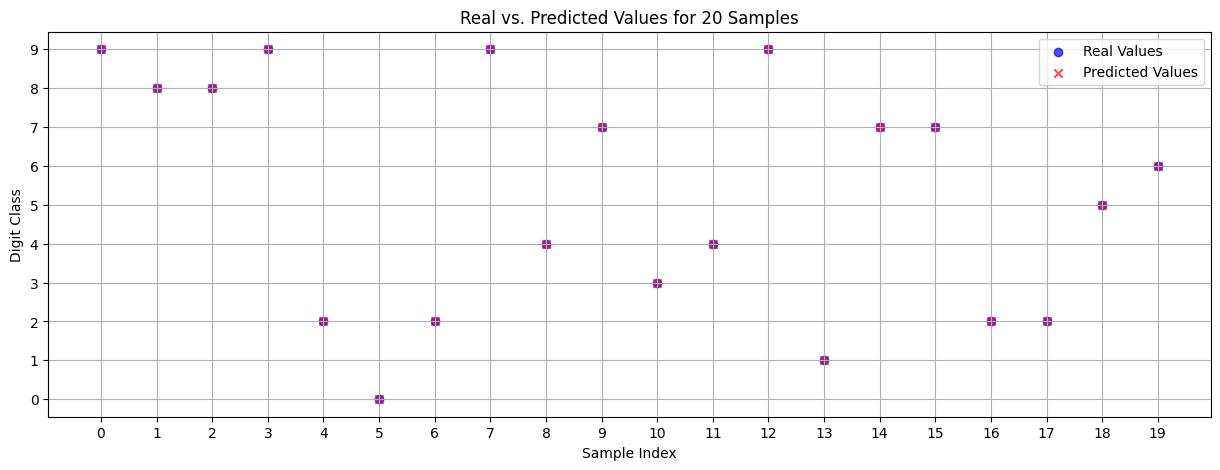

Total correct predictions: 970 out of 1000
Total incorrect predictions: 30 out of 1000


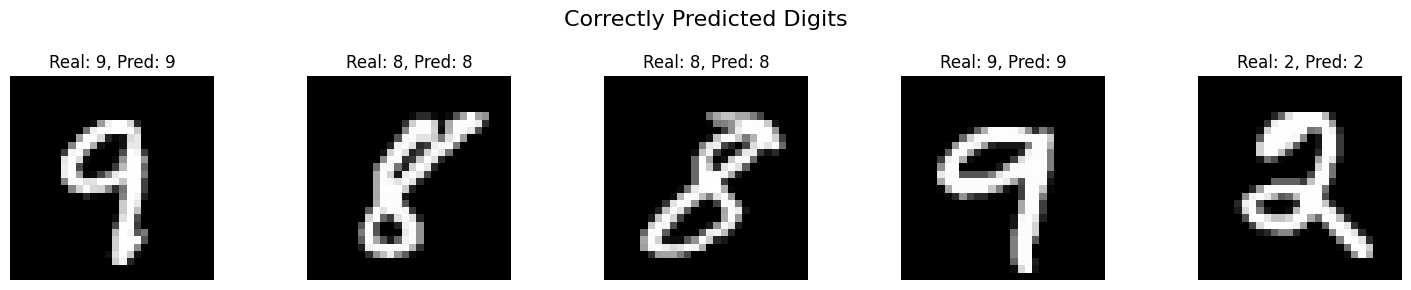

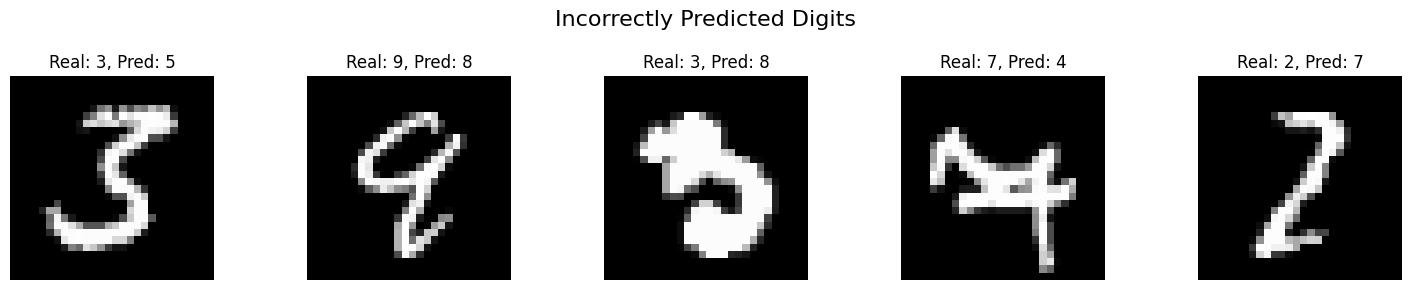

In [ ]:
import matplotlib.pyplot as plt

# Put model in evaluation mode
model.eval()

# Make predictions on the development set
with torch.inference_mode():
    test_pred_logits = model(x_dev)
    # Get the predicted class by taking the argmax over the class dimension
    predicted_classes = torch.argmax(test_pred_logits, dim=1)

# Move tensors to CPU for plotting if they are on GPU
y_dev_cpu = y_dev.cpu().numpy()
predicted_classes_cpu = predicted_classes.cpu().numpy()

# Create a figure to plot real vs predicted values for a subset
plt.figure(figsize=(15, 5))

# Plot a sample of real vs predicted values
num_samples_to_show = 20
plt.scatter(range(num_samples_to_show), y_dev_cpu[:num_samples_to_show], color='blue', label='Real Values', alpha=0.7)
plt.scatter(range(num_samples_to_show), predicted_classes_cpu[:num_samples_to_show], color='red', marker='x', label='Predicted Values', alpha=0.7)
plt.title(f'Real vs. Predicted Values for {num_samples_to_show} Samples')
plt.xlabel('Sample Index')
plt.ylabel('Digit Class')
plt.xticks(range(num_samples_to_show))
plt.yticks(range(10))
plt.legend()
plt.grid(True)
plt.show()

# Optionally, visualize some correct and incorrect predictions
correct_predictions = (predicted_classes == y_dev).nonzero(as_tuple=True)[0]
incorrect_predictions = (predicted_classes != y_dev).nonzero(as_tuple=True)[0]

print(f"Total correct predictions: {len(correct_predictions)} out of {len(y_dev)}")
print(f"Total incorrect predictions: {len(incorrect_predictions)} out of {len(y_dev)}")

# Display a few correctly predicted images
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
fig.suptitle('Correctly Predicted Digits', fontsize=16)
for i in range(min(5, len(correct_predictions))):
    idx = correct_predictions[i]
    image = x_dev[idx].cpu().numpy().reshape(28, 28)
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f'Real: {y_dev_cpu[idx]}, Pred: {predicted_classes_cpu[idx]}')
    axes[i].axis('off')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Display a few incorrectly predicted images
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
fig.suptitle('Incorrectly Predicted Digits', fontsize=16)
for i in range(min(5, len(incorrect_predictions))):
    idx = incorrect_predictions[i]
    image = x_dev[idx].cpu().numpy().reshape(28, 28)
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f'Real: {y_dev_cpu[idx]}, Pred: {predicted_classes_cpu[idx]}')
    axes[i].axis('off')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()